# Computational efficiency

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from matplotlib.ticker import ScalarFormatter

In [3]:
plt.rcParams['svg.fonttype'] = 'none'

In [4]:
methods = ['tmvec1', 'tmvec2', 'tmvec2_student', 'foldseek', 'foldseek_gpu', 'prostt5_gpu']
names = ['TM-Vec', 'TM-Vec 2', 'TM-Vec 2s', 'Foldseek', 'Foldseek GPU', 'Foldseek + ProstT5']

## Encoding

In [5]:
df = pd.read_table('encoding.tsv')
df.head()

,encoding_size,mean_seconds,method
0,10,0.355349,tmvec1
1,100,3.667599,tmvec1
2,1000,36.817476,tmvec1
3,5000,183.446004,tmvec1
4,10000,367.465977,tmvec1


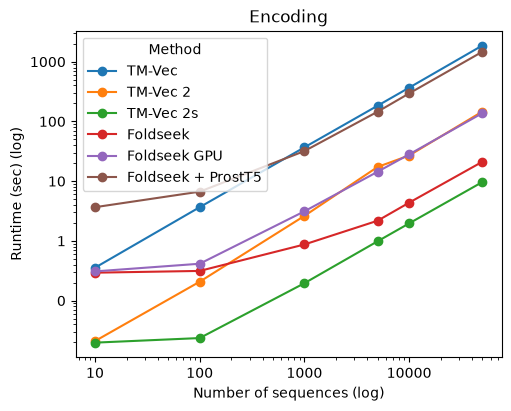

In [6]:
plt.figure(figsize=(5, 4), constrained_layout=True)
for method, name in zip(methods, names):
    df_ = df.query(f'method == "{method}"')
    plt.plot('encoding_size', 'mean_seconds', data=df_, marker='o', label=name)
plt.legend(title='Method')
plt.xscale('log')
plt.yscale('log')
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.gca().yaxis.set_major_formatter(ScalarFormatter())
plt.xlabel('Number of sequences (log)')
plt.ylabel('Runtime (sec) (log)')
plt.title('Encoding')
plt.savefig('plots/encoding.svg')

In [7]:
dfp = df.pivot(index='encoding_size', columns='method', values='mean_seconds')[methods]
dfp.columns = names
dfp

,TM-Vec,TM-Vec 2,TM-Vec 2s,Foldseek,Foldseek GPU,Foldseek + ProstT5
encoding_size,,,,,,
10,0.355349,0.021002,0.019775,0.293482,0.308346,3.664993
100,3.667599,0.207217,0.023594,0.314025,0.414396,6.673449
1000,36.817476,2.619757,0.195559,0.870917,3.125794,31.907931
5000,183.446004,17.303134,0.984628,2.175421,14.383835,145.600375
10000,367.465977,26.886962,1.963302,4.363496,28.074167,294.590060
50000,1867.914070,146.344143,9.656119,21.108768,137.644873,1468.184618


In [8]:
dfp.to_latex('encoding.tex', float_format='%.3f')

In [9]:
df['seqs_per_second'] = df['encoding_size'] / df['mean_seconds']

In [10]:
s_max = df.groupby('method')['seqs_per_second'].max().loc[methods]
s_max

method
tmvec1              28.141320
tmvec2             482.585968
tmvec2_student    5178.063995
foldseek          2368.683964
foldseek_gpu       363.253633
prostt5_gpu         34.340571
Name: seqs_per_second, dtype: float64

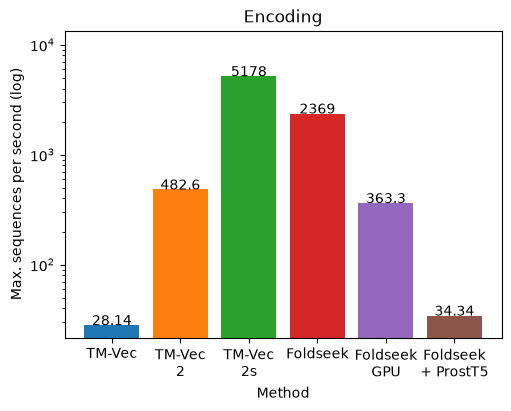

In [11]:
plt.figure(figsize=(5, 4), constrained_layout=True)
for i, method in enumerate(methods):
    plt.bar(i, height=s_max.loc[method])
    plt.text(i, s_max[method], '{:.4g}'.format(s_max[method]), ha='center')
plt.yscale('log')
plt.ylim(top=plt.ylim()[1] * 2)
plt.xlabel('Method')
plt.xticks(range(len(methods)), ['\n'.join(x.split(' ', 1)) for x in names])
plt.ylabel('Max. sequences per second (log)')
plt.title('Encoding')
plt.savefig('plots/maxseqs.svg')

Query

In [12]:
methods.append('diamond')
names.append('DIAMOND')

In [13]:
df = pd.read_table('query.tsv')
df.head()

,query_size,database_size,total_mean,method
0,10,1000,0.357020,tmvec1
1,100,1000,3.639644,tmvec1
2,1000,1000,36.834977,tmvec1
3,10,10000,0.362084,tmvec1
4,100,10000,3.711268,tmvec1


In [14]:
db_sizes = sorted(df['database_size'].unique())
db_sizes

[np.int64(1000), np.int64(10000), np.int64(100000)]

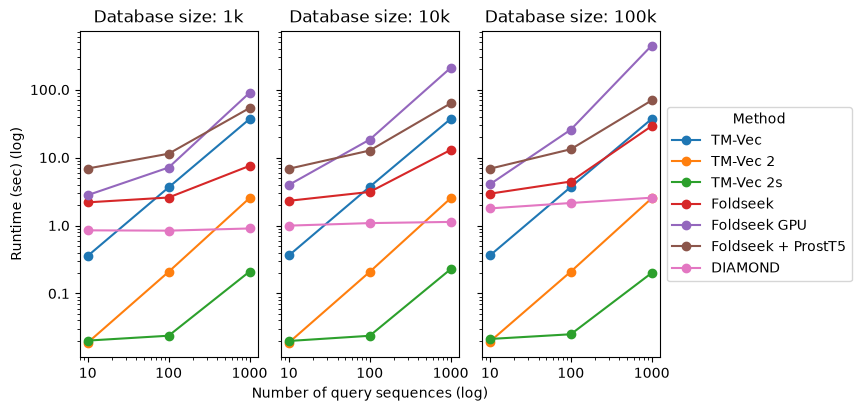

In [15]:
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(8.5, 4), constrained_layout=True)
for i, size in enumerate(db_sizes):
    ax = axes[i]
    for method, name in zip(methods, names):
        df_ = df.query(f'database_size == {size} & method == "{method}"')
        ax.plot('query_size', 'total_mean', data=df_, marker='o', label=name)
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(ScalarFormatter())
    if i == 0:
        ax.set_ylabel('Runtime (sec) (log)')
        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(ScalarFormatter())
    if i == 1:
        ax.set_xlabel('Number of query sequences (log)')
    ax.set_title(f'Database size: {int(size / 1000)}k')
    if i == 2:
        ax.legend(title='Method', loc='center left', bbox_to_anchor=(1.0, 0.5))
fig.savefig('plots/query.svg')

In [16]:
df

,query_size,database_size,total_mean,method
0,10,1000,0.357020,tmvec1
1,100,1000,3.639644,tmvec1
2,1000,1000,36.834977,tmvec1
3,10,10000,0.362084,tmvec1
4,100,10000,3.711268,tmvec1
...,...,...,...,...
58,100,10000,1.084902,diamond
59,1000,10000,1.129813,diamond
60,10,100000,1.785331,diamond
61,100,100000,2.143303,diamond


In [17]:
dfp = df.pivot(index=['query_size', 'database_size'], columns='method', values='total_mean')[methods]
dfp.columns = names
dfp

TM-Vec  TM-Vec 2  TM-Vec 2s   Foldseek  \
query_size database_size                                              
10         1000            0.357020  0.018888   0.020246   2.192699   
           10000           0.362084  0.018893   0.019980   2.309661   
           100000          0.361968  0.019581   0.021391   2.939613   
100        1000            3.639644  0.208137   0.023880   2.582282   
           10000           3.711268  0.207764   0.023829   3.118889   
           100000          3.692642  0.209456   0.025088   4.437752   
1000       1000           36.834977  2.530344   0.209667   7.539331   
           10000          37.033713  2.516688   0.227451  12.943395   
           100000         37.042440  2.516896   0.200472  29.120624   

                          Foldseek GPU  Foldseek + ProstT5   DIAMOND  
query_size database_size                                              
10         1000               2.799783            6.899768  0.849227  
           10000              3.954924            6.845581  0.995894  
           100000             4.038068            6.855854  1.785331  
100        1000               7.130292           11.393683  0.840254  
           10000             18.381501           12.697438  1.084902  
           100000            25.758633           13.264508  2.143303  
1000       1000              89.635079           53.541636  0.904498  
           10000            208.745293           62.741751  1.129813  
           100000           445.524633           69.443673  2.568086

In [18]:
dfp.reset_index(inplace=True)
dfp.to_latex('query.tex', index=False, float_format='%.3f')